# Parquet for Neuroinformatics: A Complete Guide 🧠

**A comprehensive tutorial on using Apache Parquet for efficient neuroscience data storage and analysis**

---

## Table of Contents
1. [Setup and Installation](#setup)
2. [Why Parquet? Advantages over CSV](#advantages)
3. [Understanding Parquet Structure](#structure)
4. [Working with Pandas](#pandas)
5. [Compression and Chunking Features](#features)
6. [Performance Comparisons](#performance)
7. [Polars: The Next Generation](#polars)
8. [Best Practices for Neuroinformatics](#practices)

---

## 1. Setup and Installation 🔧

First, let's install the required packages for this tutorial. Run the following cell to install everything we need:

In [29]:
# Install required packages for Google Colab
!uv pip install pandas pyarrow polars matplotlib seaborn numpy scipy

# Import all necessary libraries
import pandas as pd
import numpy as np
import polars as pl
import pyarrow as pa
import pyarrow.parquet as pq
import matplotlib.pyplot as plt
import seaborn as sns
import time
import os
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print("✅ All packages installed successfully!")
print(f"Pandas version: {pd.__version__}")
print(f"PyArrow version: {pa.__version__}")
print(f"Polars version: {pl.__version__}")

1046.72s - pydevd: Sending message related to process being replaced timed-out after 5 seconds


Checked 7 packages in 312ms
✅ All packages installed successfully!
Pandas version: 3.0.3
PyArrow version: 24.0.0
Polars version: 1.41.0


## 2. Why Parquet? Advantages over CSV 📊

### The Problem with CSV in Neuroinformatics

As neuroinformatics researchers, you've likely encountered these CSV limitations:
- **Large file sizes** for EEG/fMRI time series data
- **Slow loading times** for multi-subject datasets
- **Type inference issues** (numeric IDs becoming strings)
- **No metadata preservation** (sampling rates, channel info)
- **Poor compression** for repetitive neural data

### Parquet Solutions

| Feature | CSV | Parquet |
|---------|-----|--------|
| **File Size** | Large (text-based) | 60-90% smaller |
| **Read Speed** | Slow (parsing required) | 10-100x faster |
| **Data Types** | Lost (everything as text) | Preserved |
| **Compression** | None/ZIP | Built-in (Snappy, GZIP, LZ4) |
| **Metadata** | None | Rich schema information |
| **Chunking** | No | Native columnar chunks |
| **Filtering** | Read entire file | Push-down predicates |

## 3. Understanding Parquet Structure 🏗️

### Columnar Storage Architecture

Parquet organizes data by **columns** rather than rows, which is perfect for neuroinformatics:

```
CSV (Row-based):                 Parquet (Column-based):
subject_id,channel,timestamp,... subject_id: [1,1,1,2,2,2,...]
1,C3,0.001,0.45                  channel:   [C3,C4,F3,C3,C4,F3,...]
1,C4,0.001,0.52                  timestamp: [0.001,0.001,0.001,...]
1,F3,0.001,0.38                  value:     [0.45,0.52,0.38,...]
2,C3,0.001,0.41
...
```

### Benefits for Neural Data:
- **Channel-wise analysis**: Read only specific EEG channels
- **Time-range queries**: Filter by timestamp without reading all data
- **Statistical operations**: Mean/std per channel computed efficiently
- **Compression**: Similar values (channel names, subject IDs) compress better

In [30]:
# Let's create a synthetic neuroinformatics dataset to demonstrate
np.random.seed(42)


def create_eeg_dataset(
    n_subjects=5, n_channels=32, n_timepoints=1000, sampling_rate=500
):
    """
    Create a synthetic EEG dataset for demonstration
    """
    # EEG channel names (10-20 system)
    channels = [
        "Fp1",
        "Fp2",
        "F3",
        "F4",
        "F7",
        "F8",
        "C3",
        "C4",
        "T3",
        "T4",
        "P3",
        "P4",
        "T5",
        "T6",
        "O1",
        "O2",
        "Fz",
        "Cz",
        "Pz",
        "FC1",
        "FC2",
        "CP1",
        "CP2",
        "FC5",
        "FC6",
        "CP5",
        "CP6",
        "FT7",
        "FT8",
        "TP7",
        "TP8",
        "Oz",
    ][:n_channels]

    data = []

    for subject in range(1, n_subjects + 1):
        for timepoint in range(n_timepoints):
            timestamp = timepoint / sampling_rate  # Time in seconds

            for channel in channels:
                # Simulate EEG signal: mix of frequencies + noise
                alpha_wave = 50 * np.sin(2 * np.pi * 10 * timestamp)  # 10 Hz alpha
                beta_wave = 20 * np.sin(2 * np.pi * 20 * timestamp)  # 20 Hz beta
                noise = np.random.normal(0, 10)  # Background noise

                voltage = alpha_wave + beta_wave + noise

                data.append(
                    {
                        "subject_id": subject,
                        "channel": channel,
                        "timestamp": timestamp,
                        "voltage_uV": voltage,
                        "trial": timepoint // 100 + 1,  # 100 timepoints per trial
                        "condition": "rest" if (timepoint // 100) % 2 == 0 else "task",
                    }
                )

    return pd.DataFrame(data)


# Create our example dataset
eeg_data = create_eeg_dataset(n_subjects=3, n_channels=8, n_timepoints=500)

print(f"Dataset shape: {eeg_data.shape}")
print(f"Memory usage: {eeg_data.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print("\nFirst 10 rows:")
eeg_data.head(10)

Dataset shape: (12000, 6)
Memory usage: 0.62 MB

First 10 rows:


,subject_id,channel,timestamp,voltage_uV,trial,condition
0,1,Fp1,0.000,4.967142,1,rest
1,1,Fp2,0.000,-1.382643,1,rest
2,1,F3,0.000,6.476885,1,rest
3,1,F4,0.000,15.230299,1,rest
4,1,F7,0.000,-2.341534,1,rest
5,1,F8,0.000,-2.341370,1,rest
6,1,C3,0.000,15.792128,1,rest
7,1,C4,0.000,7.674347,1,rest
8,1,Fp1,0.002,6.545716,1,rest
9,1,Fp2,0.002,16.666060,1,rest


## 4. Working with Pandas 🐼

### Basic Parquet Operations

In [31]:
# Save as CSV and Parquet for comparison
eeg_data.to_csv('eeg_data.csv', index=False)
eeg_data.to_parquet('eeg_data.parquet', engine='pyarrow')

# Compare file sizes
csv_size = os.path.getsize('eeg_data.csv') / 1024**2
parquet_size = os.path.getsize('eeg_data.parquet') / 1024**2

print(f"CSV file size: {csv_size:.2f} MB")
print(f"Parquet file size: {parquet_size:.2f} MB")
print(f"Size reduction: {((csv_size - parquet_size) / csv_size * 100):.1f}%")

# Reading back the data
print("\n📖 Reading data back:")
%time df_csv = pd.read_csv('eeg_data.csv')
%time df_parquet = pd.read_parquet('eeg_data.parquet')

print(f"\n✅ Data integrity check: {df_csv.equals(eeg_data)}")
print(f"✅ Parquet round-trip: {df_parquet.equals(eeg_data)}")

CSV file size: 0.42 MB
Parquet file size: 0.12 MB
Size reduction: 71.5%

📖 Reading data back:
CPU times: user 490 ms, sys: 4.07 ms, total: 494 ms
Wall time: 514 ms
CPU times: user 369 ms, sys: 1.76 ms, total: 371 ms
Wall time: 373 ms

✅ Data integrity check: False
✅ Parquet round-trip: True


In [32]:
# Advanced Parquet features with pandas

# 1. Column selection (only read specific columns)
print("🔍 Reading only specific columns:")
%time channels_only = pd.read_parquet('eeg_data.parquet', columns=['subject_id', 'channel', 'voltage_uV'])
print(f"Reduced memory: {channels_only.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

# 2. Filtering while reading (predicate pushdown)
print("\n🎯 Filtering during read (predicate pushdown):")
%time subject_1_data = pd.read_parquet('eeg_data.parquet', filters=[('subject_id', '=', 1)])
print(f"Subject 1 data shape: {subject_1_data.shape}")

# 3. Data type preservation
print("\n🔢 Data types comparison:")
print("CSV data types:")
print(df_csv.dtypes)
print("\nParquet data types:")
print(df_parquet.dtypes)

🔍 Reading only specific columns:
CPU times: user 18.9 ms, sys: 918 μs, total: 19.9 ms
Wall time: 82.7 ms
Reduced memory: 0.30 MB

🎯 Filtering during read (predicate pushdown):
CPU times: user 85.3 ms, sys: 2.89 ms, total: 88.2 ms
Wall time: 169 ms
Subject 1 data shape: (4000, 6)

🔢 Data types comparison:
CSV data types:
subject_id      int64
channel           str
timestamp     float64
voltage_uV    float64
trial           int64
condition         str
dtype: object

Parquet data types:
subject_id      int64
channel           str
timestamp     float64
voltage_uV    float64
trial           int64
condition         str
dtype: object


## 5. Compression and Chunking Features ⚡

### Compression Algorithms

Parquet supports several compression algorithms, each with different trade-offs:

In [33]:
# Test different compression algorithms
compression_algorithms = ["snappy", "gzip", "lz4", "brotli"]
results = []

print("🗜️ Testing compression algorithms:")

eeg_data_test = create_eeg_dataset(n_subjects=20, n_channels=64, n_timepoints=3000)

for compression in compression_algorithms:
    try:
        filename = f"eeg_data_{compression}.parquet"

        # Time the write operation
        start_time = time.time()
        eeg_data_test.to_parquet(filename, compression=compression, engine="pyarrow")
        write_time = time.time() - start_time

        # Time the read operation
        start_time = time.time()
        _ = pd.read_parquet(filename)
        read_time = time.time() - start_time

        file_size = os.path.getsize(filename) / 1024**2

        results.append(
            {
                "compression": compression,
                "file_size_mb": file_size,
                "write_time_s": write_time,
                "read_time_s": read_time,
            }
        )

        print(
            f"{compression:8s}: {file_size:5.2f} MB, "
            f"Write: {write_time:.3f}s, Read: {read_time:.3f}s"
        )

    except Exception as e:
        print(f"{compression:8s}: Error - {e}")

# Create comparison dataframe
compression_df = pd.DataFrame(results)
compression_df

🗜️ Testing compression algorithms:
snappy  : 15.47 MB, Write: 0.499s, Read: 0.171s
gzip    : 14.69 MB, Write: 1.599s, Read: 0.274s
lz4     : 15.48 MB, Write: 0.527s, Read: 0.201s
brotli  : 14.49 MB, Write: 1.004s, Read: 0.214s


,compression,file_size_mb,write_time_s,read_time_s
0,snappy,15.466324,0.498729,0.171172
1,gzip,14.688082,1.598688,0.273583
2,lz4,15.477066,0.527029,0.201273
3,brotli,14.490369,1.004256,0.213665


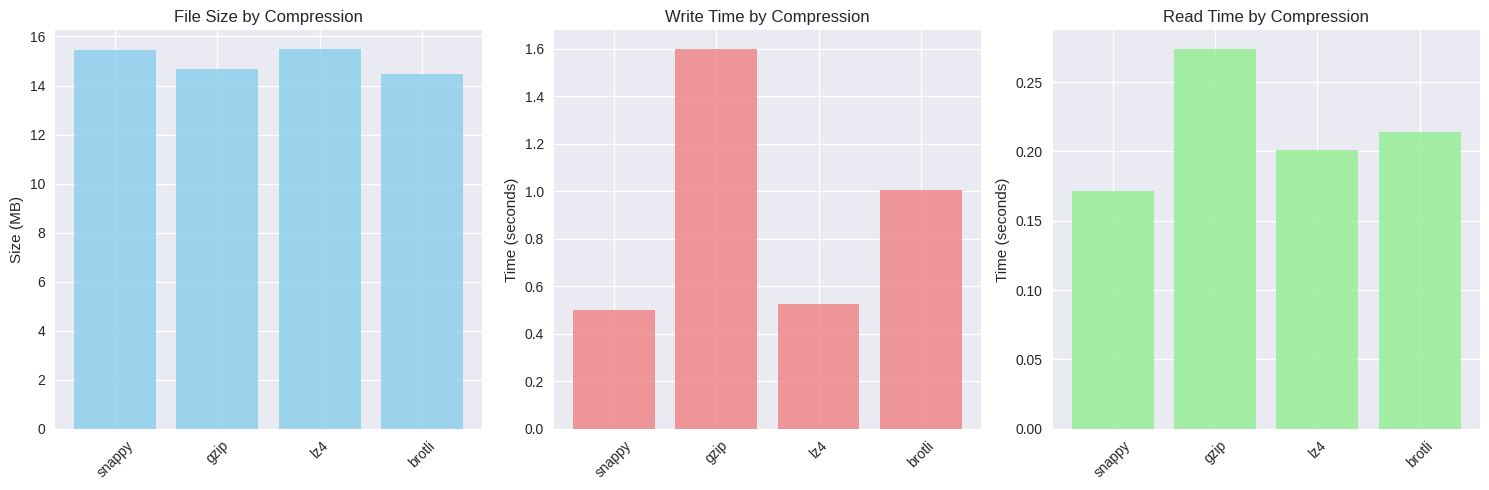


🎯 Compression Recommendations:
• **Snappy**: Best for frequent read/write operations (default)
• **GZIP**: Best compression ratio for archival storage
• **LZ4**: Fastest decompression for real-time analysis
• **Brotli**: Good balance of size and speed


In [34]:
# Visualize compression results
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# File size comparison
axes[0].bar(
    compression_df["compression"],
    compression_df["file_size_mb"],
    color="skyblue",
    alpha=0.8,
)
axes[0].set_title("File Size by Compression")
axes[0].set_ylabel("Size (MB)")
axes[0].tick_params(axis="x", rotation=45)

# Write time comparison
axes[1].bar(
    compression_df["compression"],
    compression_df["write_time_s"],
    color="lightcoral",
    alpha=0.8,
)
axes[1].set_title("Write Time by Compression")
axes[1].set_ylabel("Time (seconds)")
axes[1].tick_params(axis="x", rotation=45)

# Read time comparison
axes[2].bar(
    compression_df["compression"],
    compression_df["read_time_s"],
    color="lightgreen",
    alpha=0.8,
)
axes[2].set_title("Read Time by Compression")
axes[2].set_ylabel("Time (seconds)")
axes[2].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

# Recommendations
print("\n🎯 Compression Recommendations:")
print("• **Snappy**: Best for frequent read/write operations (default)")
print("• **GZIP**: Best compression ratio for archival storage")
print("• **LZ4**: Fastest decompression for real-time analysis")
print("• **Brotli**: Good balance of size and speed")

### Row Groups and Chunking

Parquet organizes data into **row groups** (chunks), enabling efficient parallel processing:

<img src="image.png" alt="drawing" width="600"/>

In [35]:
# Create a larger dataset to demonstrate chunking
large_eeg_data = create_eeg_dataset(n_subjects=10, n_channels=32, n_timepoints=2000)
print(f"Large dataset shape: {large_eeg_data.shape}")

# Save with different row group sizes
row_group_sizes = [1000, 5000, 10000, 50000]

print("\n📦 Testing different row group sizes:")

for row_group_size in row_group_sizes:
    filename = f"large_eeg_{row_group_size}.parquet"

    # Write with specific row group size
    table = pa.Table.from_pandas(large_eeg_data)
    pq.write_table(table, filename, row_group_size=row_group_size)

    # Analyze the resulting file
    parquet_file = pq.ParquetFile(filename)
    num_row_groups = parquet_file.num_row_groups
    file_size = os.path.getsize(filename) / 1024**2

    print(
        f"Row group size {row_group_size:5d}: {num_row_groups:2d} groups, "
        f"File size: {file_size:.2f} MB"
    )

# Demonstrate metadata inspection
print("\n🔍 Parquet metadata inspection:")
parquet_file = pq.ParquetFile("large_eeg_10000.parquet")
print(f"Schema: {parquet_file.schema}")
print(f"Number of row groups: {parquet_file.num_row_groups}")
print(f"Total rows: {parquet_file.metadata.num_rows}")

# Row group details
for i in range(min(3, parquet_file.num_row_groups)):
    rg = parquet_file.metadata.row_group(i)
    print(f"Row group {i}: {rg.num_rows} rows, {rg.total_byte_size / 1024:.1f} KB")

# Parallel read
read_times = []
print(f"\n⚡ Parallel read demonstration ({os.cpu_count()} cpus):")
for row_group_size in row_group_sizes:
    print(f"Reading with row group size {row_group_size}...")
    filename = f"large_eeg_{row_group_size}.parquet"
    start = time.time()
    df_parallel = pd.read_parquet(filename, engine="pyarrow", use_threads=True)
    read_times.append(time.time() - start)
    print(
        f"Parallel read shape: {df_parallel.shape}, Time: {read_times[-1]:.3f} seconds"
    )

Large dataset shape: (640000, 6)

📦 Testing different row group sizes:
Row group size  1000: 640 groups, File size: 6.71 MB
Row group size  5000: 128 groups, File size: 6.24 MB
Row group size 10000: 64 groups, File size: 6.22 MB
Row group size 50000: 13 groups, File size: 6.27 MB

🔍 Parquet metadata inspection:
Schema: <pyarrow._parquet.ParquetSchema object at 0x792ac05775c0>
required group field_id=-1 schema {
  optional int64 field_id=-1 subject_id;
  optional binary field_id=-1 channel (String);
  optional double field_id=-1 timestamp;
  optional double field_id=-1 voltage_uV;
  optional int64 field_id=-1 trial;
  optional binary field_id=-1 condition (String);
}

Number of row groups: 64
Total rows: 640000
Row group 0: 10000 rows, 105.5 KB
Row group 1: 10000 rows, 105.5 KB
Row group 2: 10000 rows, 105.5 KB

⚡ Parallel read demonstration (4 cpus):
Reading with row group size 1000...
Parallel read shape: (640000, 6), Time: 0.298 seconds
Reading with row group size 5000...
Parallel re

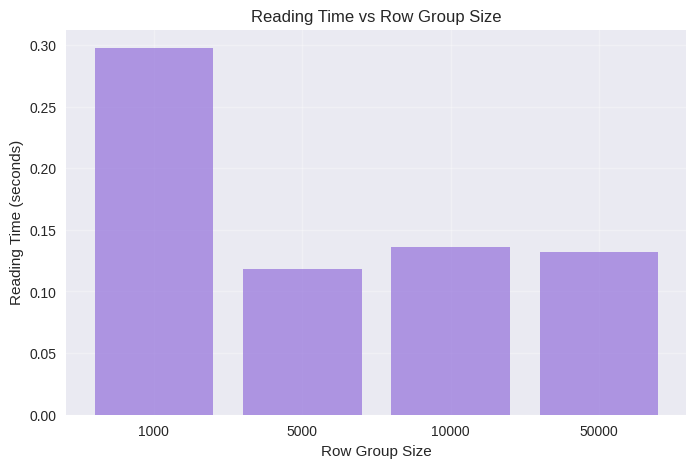

In [36]:
import numpy as np

x = np.arange(len(row_group_sizes))  # [0, 1, 2, 3]
plt.figure(figsize=(8, 5))
plt.bar(x, read_times, color="mediumpurple", alpha=0.7)
plt.title("Reading Time vs Row Group Size")
plt.xlabel("Row Group Size")
plt.ylabel("Reading Time (seconds)")
plt.grid(True, alpha=0.3)
plt.xticks(x, labels=row_group_sizes)  # show actual sizes as labels
plt.show()

## 6. Performance Comparisons 🚀

### Real-world Performance Tests

Let's run comprehensive performance tests that simulate common neuroinformatics workflows:

In [37]:
def run_performance_tests():
    """Run comprehensive performance tests"""

    # Create test datasets of different sizes
    test_sizes = [
        {"subjects": 5, "channels": 16, "timepoints": 1000, "name": "Small"},
        {"subjects": 10, "channels": 32, "timepoints": 2000, "name": "Medium"},
        {"subjects": 20, "channels": 64, "timepoints": 3000, "name": "Large"},
    ]

    results = []

    for test_config in test_sizes:
        print(f"\n🧪 Testing {test_config['name']} dataset...")

        # Create dataset
        test_data = create_eeg_dataset(
            n_subjects=test_config["subjects"],
            n_channels=test_config["channels"],
            n_timepoints=test_config["timepoints"],
        )

        dataset_name = test_config["name"].lower()
        csv_file = f"test_{dataset_name}.csv"
        parquet_file = f"test_{dataset_name}.parquet"

        # Test CSV operations
        print("  📄 Testing CSV...")
        start = time.time()
        test_data.to_csv(csv_file, index=False)
        csv_write_time = time.time() - start

        start = time.time()
        _ = pd.read_csv(csv_file)
        csv_read_time = time.time() - start

        csv_size = os.path.getsize(csv_file) / 1024**2

        # Test Parquet operations
        print("  📦 Testing Parquet...")
        start = time.time()
        test_data.to_parquet(parquet_file, compression="snappy")
        parquet_write_time = time.time() - start

        start = time.time()
        _ = pd.read_parquet(parquet_file)
        parquet_read_time = time.time() - start

        parquet_size = os.path.getsize(parquet_file) / 1024**2

        # Test partial reading (common neuroinformatics operation)
        start = time.time()
        _ = pd.read_parquet(
            parquet_file,
            columns=["subject_id", "channel", "voltage_uV"],
            filters=[("subject_id", "<=", 2)],
        )
        parquet_partial_read_time = time.time() - start

        # Store results
        results.append(
            {
                "dataset": test_config["name"],
                "rows": len(test_data),
                "csv_size_mb": csv_size,
                "parquet_size_mb": parquet_size,
                "size_reduction_%": (1 - parquet_size / csv_size) * 100,
                "csv_write_s": csv_write_time,
                "parquet_write_s": parquet_write_time,
                "csv_read_s": csv_read_time,
                "parquet_read_s": parquet_read_time,
                "parquet_partial_read_s": parquet_partial_read_time,
                "read_speedup": csv_read_time / parquet_read_time,
                "write_speedup": csv_write_time / parquet_write_time,
            }
        )

        print(
            f"    Size: CSV {csv_size:.1f}MB → Parquet {parquet_size:.1f}MB "
            f"({((csv_size-parquet_size)/csv_size*100):.1f}% reduction)"
        )
        print(
            f"    Read: CSV {csv_read_time:.2f}s → Parquet {parquet_read_time:.2f}s "
            f"({csv_read_time/parquet_read_time:.1f}x faster)"
        )

    return pd.DataFrame(results)


# Run the tests
performance_results = run_performance_tests()
print("\n📊 Performance Summary:")
performance_results


🧪 Testing Small dataset...
  📄 Testing CSV...
  📦 Testing Parquet...
    Size: CSV 2.8MB → Parquet 0.8MB (71.9% reduction)
    Read: CSV 0.13s → Parquet 0.02s (7.8x faster)

🧪 Testing Medium dataset...
  📄 Testing CSV...
  📦 Testing Parquet...
    Size: CSV 23.0MB → Parquet 5.2MB (77.2% reduction)
    Read: CSV 0.62s → Parquet 0.08s (7.9x faster)

🧪 Testing Large dataset...
  📄 Testing CSV...
  📦 Testing Parquet...
    Size: CSV 70.1MB → Parquet 15.5MB (77.9% reduction)
    Read: CSV 2.08s → Parquet 0.19s (11.0x faster)

📊 Performance Summary:


,dataset,rows,csv_size_mb,parquet_size_mb,size_reduction_%,csv_write_s,parquet_write_s,csv_read_s,parquet_read_s,parquet_partial_read_s,read_speedup,write_speedup
0,Small,80000,2.810465,0.789307,71.915442,0.747167,0.078331,0.131464,0.016878,0.023834,7.788892,9.538524
1,Medium,640000,23.011679,5.243956,77.211764,4.223083,0.202100,0.617812,0.077996,0.064307,7.921052,20.896027
2,Large,1920000,70.133294,15.466322,77.947247,11.709926,0.598028,2.080072,0.188365,0.052383,11.042747,19.580885


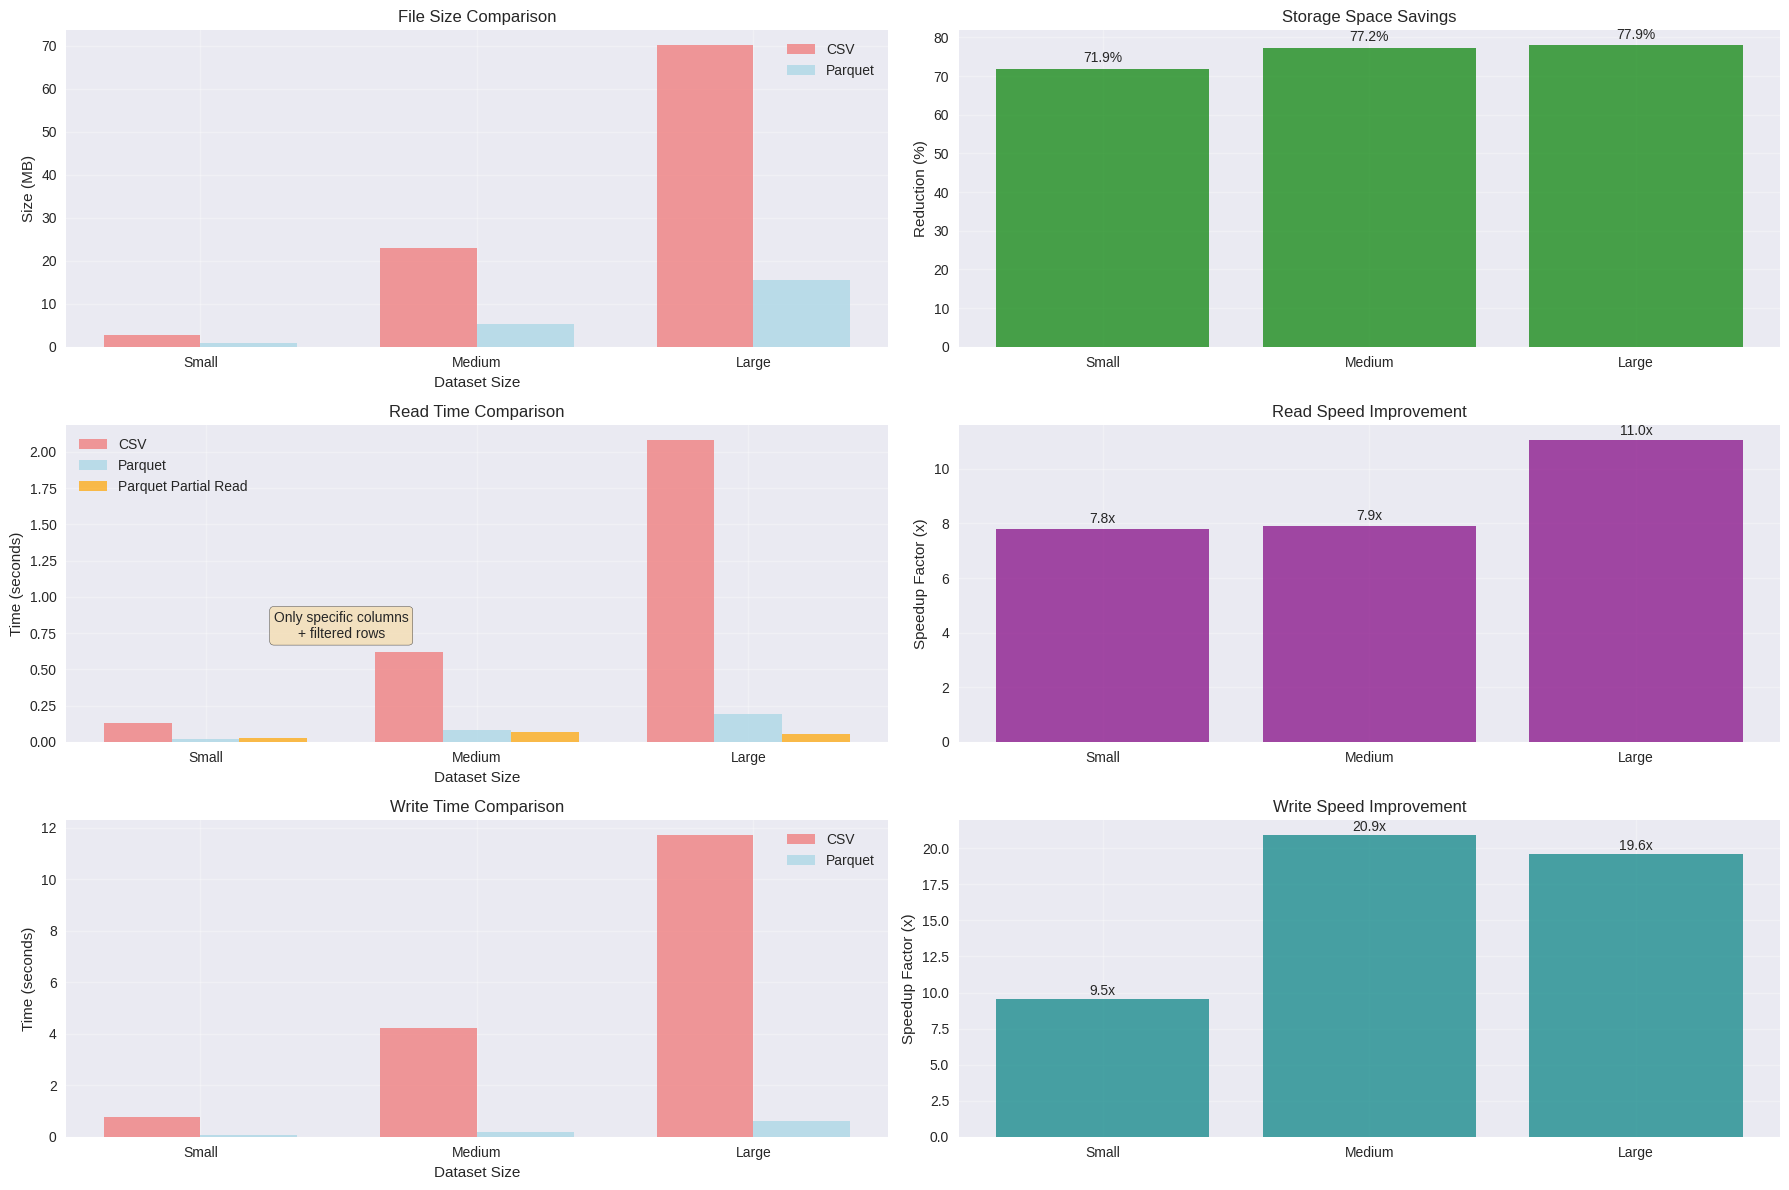

In [38]:
# Visualize performance results
fig, axes = plt.subplots(3, 2, figsize=(18, 12))

# File size comparison
x = range(len(performance_results))
width = 0.35
axes[0, 0].bar(
    [i - width / 2 for i in x],
    performance_results["csv_size_mb"],
    width,
    label="CSV",
    color="lightcoral",
    alpha=0.8,
)
axes[0, 0].bar(
    [i + width / 2 for i in x],
    performance_results["parquet_size_mb"],
    width,
    label="Parquet",
    color="lightblue",
    alpha=0.8,
)
axes[0, 0].set_title("File Size Comparison")
axes[0, 0].set_ylabel("Size (MB)")
axes[0, 0].set_xlabel("Dataset Size")
axes[0, 0].set_xticks(x)
axes[0, 0].set_xticklabels(performance_results["dataset"])
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Size reduction percentage
axes[0, 1].bar(
    performance_results["dataset"],
    performance_results["size_reduction_%"],
    color="green",
    alpha=0.7,
)
axes[0, 1].set_title("Storage Space Savings")
axes[0, 1].set_ylabel("Reduction (%)")
axes[0, 1].grid(True, alpha=0.3)
for i, v in enumerate(performance_results["size_reduction_%"]):
    axes[0, 1].text(i, v + 1, f"{v:.1f}%", ha="center", va="bottom")

# Read time comparison
width = 0.25
axes[1, 0].bar(
    [i - width for i in x],
    performance_results["csv_read_s"],
    width,
    label="CSV",
    color="lightcoral",
    alpha=0.8,
)
axes[1, 0].bar(
    [i for i in x],
    performance_results["parquet_read_s"],
    width,
    label="Parquet",
    color="lightblue",
    alpha=0.8,
)
axes[1, 0].bar(
    [i + width for i in x],
    performance_results["parquet_partial_read_s"],
    width,
    color="orange",
    alpha=0.7,
    label="Parquet Partial Read",
)
axes[1, 0].set_title("Read Time Comparison")
axes[1, 0].set_ylabel("Time (seconds)")
axes[1, 0].set_xlabel("Dataset Size")
axes[1, 0].set_xticks(x)
axes[1, 0].set_xticklabels(performance_results["dataset"])
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)
# Partial read performance (Parquet advantage)
axes[1, 0].text(
    0.5,
    0.8,
    "Only specific columns\n+ filtered rows",
    ha="center",
    va="center",
    bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.8),
)

# Read speedup
axes[1, 1].bar(
    performance_results["dataset"],
    performance_results["read_speedup"],
    color="purple",
    alpha=0.7,
)
axes[1, 1].set_title("Read Speed Improvement")
axes[1, 1].set_ylabel("Speedup Factor (x)")
axes[1, 1].grid(True, alpha=0.3)
for i, v in enumerate(performance_results["read_speedup"]):
    axes[1, 1].text(i, v + 0.1, f"{v:.1f}x", ha="center", va="bottom")


# Write time comparison
width = 0.35
axes[2, 0].bar(
    [i - width / 2 for i in x],
    performance_results["csv_write_s"],
    width,
    label="CSV",
    color="lightcoral",
    alpha=0.8,
)
axes[2, 0].bar(
    [i + width / 2 for i in x],
    performance_results["parquet_write_s"],
    width,
    label="Parquet",
    color="lightblue",
    alpha=0.8,
)
axes[2, 0].set_title("Write Time Comparison")
axes[2, 0].set_ylabel("Time (seconds)")
axes[2, 0].set_xlabel("Dataset Size")
axes[2, 0].set_xticks(x)
axes[2, 0].set_xticklabels(performance_results["dataset"])
axes[2, 0].legend()
axes[2, 0].grid(True, alpha=0.3)

# Write speedup
axes[2, 1].bar(
    performance_results["dataset"],
    performance_results["write_speedup"],
    color="teal",
    alpha=0.7,
)
axes[2, 1].set_title("Write Speed Improvement")
axes[2, 1].set_ylabel("Speedup Factor (x)")
axes[2, 1].grid(True, alpha=0.3)
for i, v in enumerate(performance_results["write_speedup"]):
    axes[2, 1].text(i, v + 0.1, f"{v:.1f}x", ha="center", va="bottom")

plt.tight_layout()
plt.show()

### Real Neuroinformatics Use Cases

In [39]:
# Common neuroinformatics analysis patterns with Parquet

print("🧠 Common Neuroinformatics Analysis Patterns with Parquet")
print("=" * 60)

# 1. Channel-specific analysis
print("\n1. 📊 Analyzing specific EEG channels:")
%time frontal_channels = pd.read_parquet('large_eeg_10000.parquet', columns=['subject_id', 'channel', 'voltage_uV', 'timestamp'], filters=[('channel', 'in', ['Fp1', 'Fp2', 'F3', 'F4'])])
print(f"Frontal channels data shape: {frontal_channels.shape}")

# 2. Subject-specific analysis
print("\n2. 👤 Single subject analysis:")
%time subject_data = pd.read_parquet('large_eeg_10000.parquet', filters=[('subject_id', '=', 1)])
print(f"Subject 1 data shape: {subject_data.shape}")

# 3. Time window analysis
print("\n3. ⏰ Time window analysis (first 2 seconds):")
%time time_window = pd.read_parquet('large_eeg_10000.parquet', filters=[('timestamp', '<=', 2.0)])
print(f"Time window data shape: {time_window.shape}")

# 4. Condition-based analysis
print("\n4. 🎯 Condition-based analysis (task vs rest):")
%time task_data = pd.read_parquet('large_eeg_10000.parquet', columns=['subject_id', 'channel', 'voltage_uV', 'condition'], filters=[('condition', '=', 'task')])
print(f"Task condition data shape: {task_data.shape}")

# 5. Statistical summary by channel
print("\n5. 📈 Channel-wise statistics:")
channel_stats = (
    pd.read_parquet('large_eeg_10000.parquet',
                   columns=['channel', 'voltage_uV'])
    .groupby('channel')['voltage_uV']
    .agg(['mean', 'std', 'min', 'max'])
    .round(2)
)
print(channel_stats.head(10))

🧠 Common Neuroinformatics Analysis Patterns with Parquet

1. 📊 Analyzing specific EEG channels:
CPU times: user 110 ms, sys: 4.38 ms, total: 114 ms
Wall time: 203 ms
Frontal channels data shape: (80000, 4)

2. 👤 Single subject analysis:
CPU times: user 27.7 ms, sys: 1.86 ms, total: 29.5 ms
Wall time: 67.7 ms
Subject 1 data shape: (64000, 6)

3. ⏰ Time window analysis (first 2 seconds):
CPU times: user 115 ms, sys: 9.73 ms, total: 124 ms
Wall time: 267 ms
Time window data shape: (320320, 6)

4. 🎯 Condition-based analysis (task vs rest):
CPU times: user 148 ms, sys: 13 ms, total: 161 ms
Wall time: 155 ms
Task condition data shape: (320000, 4)

5. 📈 Channel-wise statistics:
         mean    std    min     max
channel                            
C3       0.08  39.47 -91.84   95.28
C4       0.09  39.37 -88.50  104.22
CP1      0.00  39.40 -95.78   92.26
CP2      0.00  39.38 -92.76   96.22
CP5     -0.08  39.37 -93.43   94.47
CP6      0.06  39.35 -88.70   97.37
Cz       0.04  39.47 -96.49   95

## 7. Partitioned Parquet Files for Faster Queries 📂

### What is Partitioning?

Partitioning splits a dataset across multiple files organised in a **Hive-style directory tree**:

```
eeg_partitioned/
├── subject_id=1/
│   └── part-0.parquet
├── subject_id=2/
│   └── part-0.parquet
└── ...
```

When you filter on the partition column, the query engine **skips entire directories** without opening a single file — this is called **partition pruning**, and it's far faster than row-group-level filtering.

### When to Partition

| Partition key | Good when... |
|---|---|
| `subject_id` | Per-subject analyses are the primary access pattern |
| `condition` | Comparing task vs. rest in isolation |
| `subject_id` + `condition` | Both patterns appear frequently |

**Avoid** high-cardinality columns (e.g. `timestamp`, `channel`) — too many tiny files hurt rather than help.

In [54]:
import pyarrow.dataset as ds
import subprocess

# Write partitioned by subject_id (Hive layout)
ds.write_dataset(
    pa.Table.from_pandas(large_eeg_data),
    "eeg_partitioned",
    format="parquet",
    partitioning=ds.partitioning(
        pa.schema([("subject_id", pa.int64())]),
        flavor="hive"
    ),
    existing_data_behavior="overwrite_or_ignore"
)

# Show directory structure
result = subprocess.run(["find", "eeg_partitioned", "-name", "*.parquet"],
                        capture_output=True, text=True)
print("Partition layout:")
for line in sorted(result.stdout.strip().split("\n")):
    print(" ", line)


Partition layout:
  eeg_partitioned/subject_id=1/part-0.parquet
  eeg_partitioned/subject_id=10/part-0.parquet
  eeg_partitioned/subject_id=2/part-0.parquet
  eeg_partitioned/subject_id=3/part-0.parquet
  eeg_partitioned/subject_id=4/part-0.parquet
  eeg_partitioned/subject_id=5/part-0.parquet
  eeg_partitioned/subject_id=6/part-0.parquet
  eeg_partitioned/subject_id=7/part-0.parquet
  eeg_partitioned/subject_id=8/part-0.parquet
  eeg_partitioned/subject_id=9/part-0.parquet


In [55]:
# ── Single-level partition pruning ───────────────────────────────────────

# Full scan — reads all partition directories
t0 = time.time()
df_full_part = pd.read_parquet("eeg_partitioned")
t_full_part = time.time() - t0
print(f"Full scan : {df_full_part.shape}  Time: {t_full_part:.3f} s")

# Partition-pruned — only opens the subject_id=1 directory
t0 = time.time()
df_pruned = pd.read_parquet("eeg_partitioned", filters=[("subject_id", "=", 1)])
t_pruned = time.time() - t0
print(f"Pruned read (subject_id=1): {df_pruned.shape}  Time: {t_pruned:.3f} s")

n_subjects = large_eeg_data['subject_id'].nunique()
print(f"\nSpeedup: {t_full_part / t_pruned:.1f}x"
      f" (theoretical max: {n_subjects}x for {n_subjects} subjects)")


Full scan : (640000, 6)  Time: 0.402 s
Pruned read (subject_id=1): (64000, 6)  Time: 0.034 s

Speedup: 11.8x (theoretical max: 10x for 10 subjects)


In [56]:
# ── Multi-level partitioning: subject_id + condition ─────────────────────

ds.write_dataset(
    pa.Table.from_pandas(large_eeg_data),
    "eeg_partitioned_multi",
    format="parquet",
    partitioning=ds.partitioning(
        pa.schema([("subject_id", pa.int64()), ("condition", pa.string())]),
        flavor="hive"
    ),
    existing_data_behavior="overwrite_or_ignore"
)

# Read only task data for subject 1 — two partition levels pruned
t0 = time.time()
df_task_s1 = pd.read_parquet(
    "eeg_partitioned_multi",
    filters=[("subject_id", "=", 1), ("condition", "=", "task")]
)
t_task_s1 = time.time() - t0
print(f"subject_id=1 + condition=task: {df_task_s1.shape}  Time: {t_task_s1:.3f} s")

# Show a slice of the tree
result = subprocess.run(["find", "eeg_partitioned_multi", "-name", "*.parquet"],
                        capture_output=True, text=True)
print("\nMulti-level layout (first 8 files):")
for line in sorted(result.stdout.strip().split("\n"))[:8]:
    print(" ", line)


subject_id=1 + condition=task: (32000, 6)  Time: 0.060 s

Multi-level layout (first 8 files):
  eeg_partitioned_multi/subject_id=1/condition=rest/part-0.parquet
  eeg_partitioned_multi/subject_id=1/condition=task/part-0.parquet
  eeg_partitioned_multi/subject_id=10/condition=rest/part-0.parquet
  eeg_partitioned_multi/subject_id=10/condition=task/part-0.parquet
  eeg_partitioned_multi/subject_id=2/condition=rest/part-0.parquet
  eeg_partitioned_multi/subject_id=2/condition=task/part-0.parquet
  eeg_partitioned_multi/subject_id=3/condition=rest/part-0.parquet
  eeg_partitioned_multi/subject_id=3/condition=task/part-0.parquet


In [57]:
# ── Polars lazy scan with Hive partition awareness ────────────────────────

t0 = time.time()
df_polars_pruned = (
    pl.scan_parquet("eeg_partitioned/**/*.parquet", hive_partitioning=True)
    .filter(pl.col('subject_id') == 1)
    .collect()
)
print(f"Polars pruned read: {df_polars_pruned.shape}  Time: {time.time() - t0:.3f} s")
print(df_polars_pruned.head())


Polars pruned read: (64000, 6)  Time: 0.283 s
shape: (5, 6)
┌─────────┬───────────┬────────────┬───────┬───────────┬────────────┐
│ channel ┆ timestamp ┆ voltage_uV ┆ trial ┆ condition ┆ subject_id │
│ ---     ┆ ---       ┆ ---        ┆ ---   ┆ ---       ┆ ---        │
│ str     ┆ f64       ┆ f64        ┆ i64   ┆ str       ┆ i64        │
╞═════════╪═══════════╪════════════╪═══════╪═══════════╪════════════╡
│ Fp1     ┆ 0.0       ┆ 2.284799   ┆ 1     ┆ rest      ┆ 1          │
│ Fp2     ┆ 0.0       ┆ -6.024072  ┆ 1     ┆ rest      ┆ 1          │
│ F3      ┆ 0.0       ┆ -1.129266  ┆ 1     ┆ rest      ┆ 1          │
│ F4      ┆ 0.0       ┆ -4.968148  ┆ 1     ┆ rest      ┆ 1          │
│ F7      ┆ 0.0       ┆ -14.682401 ┆ 1     ┆ rest      ┆ 1          │
└─────────┴───────────┴────────────┴───────┴───────────┴────────────┘


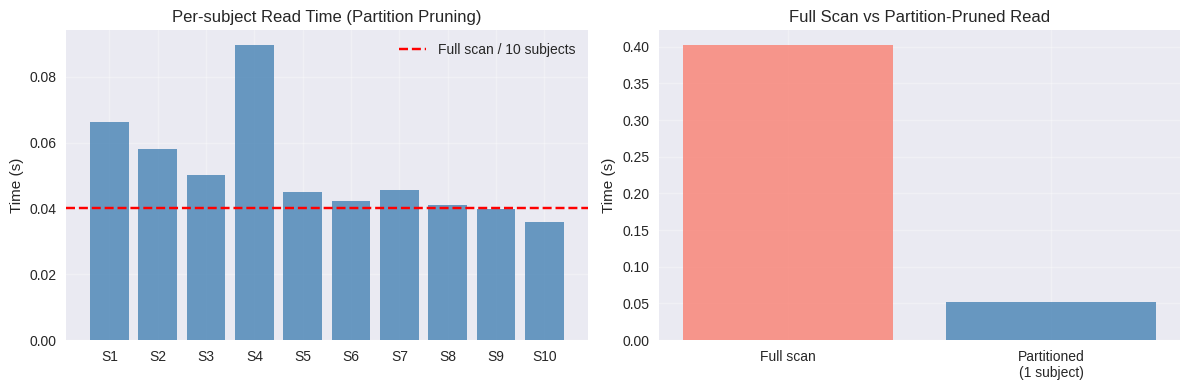

In [58]:
# ── Visualise partition-pruning speedup ──────────────────────────────────

import numpy as np

subjects = sorted(large_eeg_data['subject_id'].unique())
pruned_times = []
for sid in subjects:
    t0 = time.time()
    pd.read_parquet("eeg_partitioned", filters=[("subject_id", "=", sid)])
    pruned_times.append(time.time() - t0)

x = np.arange(len(subjects))
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(x, pruned_times, color='steelblue', alpha=0.8)
axes[0].axhline(t_full_part / len(subjects), color='red', linestyle='--',
                label=f'Full scan / {len(subjects)} subjects')
axes[0].set_xticks(x)
axes[0].set_xticklabels([f'S{s}' for s in subjects])
axes[0].set_title('Per-subject Read Time (Partition Pruning)')
axes[0].set_ylabel('Time (s)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].bar(['Full scan', 'Partitioned\n(1 subject)'],
            [t_full_part, np.mean(pruned_times)],
            color=['salmon', 'steelblue'], alpha=0.8)
axes[1].set_title('Full Scan vs Partition-Pruned Read')
axes[1].set_ylabel('Time (s)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 8. Polars: The Next Generation 🚀

### Why Polars for Neuroinformatics?

**Polars** is a blazingly fast DataFrame library built in Rust with Python bindings. It's designed from the ground up for performance and handles Parquet files natively.

**Key advantages over Pandas:**
- **Speed**: 10-100x faster for many operations
- **Memory efficiency**: Better memory management
- **Lazy evaluation**: Optimizes query plans automatically
- **Native Parquet support**: Built-in optimizations
- **Better API**: More intuitive for data transformations

In [40]:
# Basic Polars operations with our EEG data
print("🚀 Polars Basic Operations")
print("=" * 30)

# Read with Pandas
print("\n📖 Reading Parquet with Pandas:")
%time df_pandas = pd.read_parquet('large_eeg_10000.parquet')
print(f"Shape: {df_pandas.shape}")
print(f"Schema: {df_pandas.dtypes}")

# Read with Polars
print("\n📖 Reading Parquet with Polars:")
%time df_polars = pl.read_parquet('large_eeg_10000.parquet')
print(f"Shape: {df_polars.shape}")
print(f"Schema: {df_polars.schema}")

# Compare memory usage
print(f"\nMemory comparison:")
pandas_memory = df_pandas.memory_usage(deep=True).sum()
polars_memory = df_polars.estimated_size()
print(f"Pandas memory: {pandas_memory / 1024**2:.2f} MB")
print(f"Polars memory: {polars_memory / 1024**2:.2f} MB")
print(f"Memory reduction: {(1 - polars_memory/pandas_memory)*100:.1f}%")

# First few rows
print("\nFirst 5 rows:")
df_polars.head()

🚀 Polars Basic Operations

📖 Reading Parquet with Pandas:
CPU times: user 155 ms, sys: 10.3 ms, total: 166 ms
Wall time: 114 ms
Shape: (640000, 6)
Schema: subject_id      int64
channel           str
timestamp     float64
voltage_uV    float64
trial           int64
condition         str
dtype: object

📖 Reading Parquet with Polars:
CPU times: user 369 ms, sys: 43.6 ms, total: 413 ms
Wall time: 445 ms
Shape: (640000, 6)
Schema: Schema({'subject_id': Int64, 'channel': String, 'timestamp': Float64, 'voltage_uV': Float64, 'trial': Int64, 'condition': String})

Memory comparison:
Pandas memory: 33.23 MB
Polars memory: 23.46 MB
Memory reduction: 29.4%

First 5 rows:


subject_id,channel,timestamp,voltage_uV,trial,condition
i64,str,f64,f64,i64,str
1,"""Fp1""",0.0,2.284799,1,"""rest"""
1,"""Fp2""",0.0,-6.024072,1,"""rest"""
1,"""F3""",0.0,-1.129266,1,"""rest"""
1,"""F4""",0.0,-4.968148,1,"""rest"""
1,"""F7""",0.0,-14.682401,1,"""rest"""


### Lazy evaluation



In [41]:
from polars import QueryOptFlags

# Polars Lazy Evaluation (Game Changer for Large Datasets)
print("🧠 Polars Lazy Evaluation - The Game Changer")
print("=" * 50)

# Create a lazy frame (doesn't load data until needed)
lazy_df = pl.scan_parquet('large_eeg_10000.parquet')

# Build a complex query without executing it
complex_query = (
    lazy_df
    .filter(pl.col('subject_id') <= 5)  # Filter subjects
    .filter(pl.col('channel').is_in(['C3', 'C4', 'Cz']))  # Select channels
    .with_columns([
        (pl.col('voltage_uV').abs()).alias('abs_voltage'),  # Add absolute voltage
        (pl.col('voltage_uV') ** 2).alias('power')  # Add power
    ])
    .group_by(['subject_id', 'channel', 'condition'])
    .agg([
        pl.col('voltage_uV').mean().alias('mean_voltage'),
        pl.col('voltage_uV').std().alias('std_voltage'),
        pl.col('abs_voltage').mean().alias('mean_abs_voltage'),
        pl.col('power').mean().alias('mean_power'),
        pl.len().alias('count')
    ])
    .sort(['subject_id', 'channel', 'condition'])
)

print("Non-optimized query plan (before execution):")
print(complex_query.explain(optimized=False), end="\n\n")


print("Query plan (before execution):")
'''
engine
Select the engine used to process the query (default "auto"):

"auto": use the engine set by Config.set_engine_affinity <polars.Config.set_engine_affinity> or the POLARS_ENGINE_AFFINITY environment variable, falling back to "in-memory" if unset (this default may change in a future release).
"in-memory": use the in-memory engine, this is the default engine.
"streaming": use the streaming engine, which processes queries in batches, reducing memory pressure and often outperforming the in-memory engine. This will soon become the default engine of Polars.
"gpu": use the CUDA GPU engine (requires an Nvidia GPU and cudf-polars). Pass a GPUEngine object for fine-grained control (e.g. device selection on multi-GPU systems).
'''
print(complex_query.explain())

# Execute the non-optimized query
print("\n Executing non-optimized query:")
%time result = complex_query.collect(optimizations=QueryOptFlags.none())
print(f"Result shape: {result.shape}")


# Execute the optimized query
print("\n⚡ Executing optimized query:")
%time result = complex_query.collect()
print(f"Result shape: {result.shape}")
result.head(10)

🧠 Polars Lazy Evaluation - The Game Changer
Non-optimized query plan (before execution):
SORT BY [col("subject_id"), col("channel"), col("condition")]
  AGGREGATE[maintain_order: false]
    [col("voltage_uV").mean().alias("mean_voltage"), col("voltage_uV").std().alias("std_voltage"), col("abs_voltage").mean().alias("mean_abs_voltage"), col("power").mean().alias("mean_power"), len().alias("count")] BY [col("subject_id"), col("channel"), col("condition")]
    FROM
     WITH_COLUMNS:
     [col("voltage_uV").abs().alias("abs_voltage"), col("voltage_uV").pow([dyn int: 2]).alias("power")] 
      FILTER col("channel").is_in([["C3", "C4", "Cz"]])
      FROM
        FILTER [(col("subject_id")) <= (5)]
        FROM
          Parquet SCAN [large_eeg_10000.parquet]
          PROJECT */6 COLUMNS
          ESTIMATED ROWS: 640000

Query plan (before execution):
SORT BY [col("subject_id"), col("channel"), col("condition")]
  AGGREGATE[maintain_order: false]
    [col("voltage_uV").mean().alias("mean_vo

subject_id,channel,condition,mean_voltage,std_voltage,mean_abs_voltage,mean_power,count
i64,str,str,f64,f64,f64,f64,u32
1,"""C3""","""rest""",0.639791,39.998092,33.589308,1598.656885,1000
1,"""C3""","""task""",0.135864,39.647687,32.980487,1570.385583,1000
1,"""C4""","""rest""",0.254437,39.49839,32.973047,1558.627412,1000
1,"""C4""","""task""",0.270089,38.991846,32.80475,1518.916665,1000
1,"""Cz""","""rest""",0.085074,39.41857,33.023943,1552.277094,1000
1,"""Cz""","""task""",0.079434,39.244828,32.91108,1538.622695,1000
2,"""C3""","""rest""",-0.011652,39.421325,33.214918,1552.48697,1000
2,"""C3""","""task""",-0.546123,39.281412,33.021387,1541.784517,1000
2,"""C4""","""rest""",-0.313344,39.552084,33.152943,1562.901129,1000


In [43]:
# Performance comparison: Polars vs Pandas
print("⚔️ Polars vs Pandas Performance Battle")
print("=" * 40)

# Test 1: Groupby aggregation
print("\n🥊 Round 1: Group by channel and compute statistics")

# Pandas version
print("Pandas:")
%time pandas_result = (pd.read_parquet('large_eeg_10000.parquet').groupby('channel')['voltage_uV'].agg(['mean', 'std', 'count']).round(3))

# Polars version
print("\nPolars:")
%time polars_result = (pl.read_parquet('large_eeg_10000.parquet').group_by('channel').agg([pl.col('voltage_uV').mean().round(3).alias('mean'),pl.col('voltage_uV').std().round(3).alias('std'),pl.len().alias('count')]).sort('channel'))

print(f"\nResults shape - Pandas: {pandas_result.shape}, Polars: {polars_result.shape}")

# Test 2: Complex filtering and transformation
print("\n🥊 Round 2: Complex filtering and feature engineering")

# Pandas version
print("Pandas:")
_t = time.time()
pandas_complex = (
  pd.read_parquet("large_eeg_10000.parquet")
  .rename(columns=lambda c: c.strip())  # prevents KeyError from accidental spaces
  .query('subject_id <= 3 and condition == "task"')
  .assign(
    voltage_squared=lambda x: x["voltage_uV"] ** 2,
    voltage_normalized=lambda x: (
      (x["voltage_uV"] - x["voltage_uV"].mean()) / x["voltage_uV"].std()
    ),
  )
  .groupby(["subject_id", "channel"])
  .agg(
    voltage_mean=("voltage_uV", "mean"),
    voltage_max=("voltage_uV", "max"),
    voltage_min=("voltage_uV", "min"),
    voltage_squared_mean=("voltage_squared", "mean"),
    voltage_normalized_std=("voltage_normalized", "std"),
  )
  .round(3)
)
print(f"Wall time: {time.time() - _t:.3f} s")

# Polars version (with lazy evaluation)
print("\nPolars (Lazy):")
%time polars_complex = (pl.scan_parquet('large_eeg_10000.parquet').filter((pl.col('subject_id') <= 3) & (pl.col('condition') == 'task')).with_columns([(pl.col('voltage_uV') ** 2).alias('voltage_squared'),((pl.col('voltage_uV') - pl.col('voltage_uV').mean()) / pl.col('voltage_uV').std()).alias('voltage_normalized')]).group_by(['subject_id', 'channel']).agg([pl.col('voltage_uV').mean().round(3).alias('voltage_mean'),pl.col('voltage_uV').max().round(3).alias('voltage_max'),pl.col('voltage_uV').min().round(3).alias('voltage_min'),pl.col('voltage_squared').mean().round(3).alias('voltage_squared_mean'),pl.col('voltage_normalized').std().round(3).alias('voltage_normalized_std')]).sort(['subject_id', 'channel']).collect())

print(f"\nComplex results - Pandas: {pandas_complex.shape}, Polars: {polars_complex.shape}")

# Test 3: Reading with filters (predicate pushdown)
print("\n🥊 Round 3: Reading with filters (predicate pushdown)")

# Pandas
print("Pandas:")
%time pandas_filtered = pd.read_parquet('large_eeg_10000.parquet', filters=[('subject_id', '<=', 2), ('condition', '=', 'rest')])

# Polars
print("\nPolars:")
%time polars_filtered = (pl.scan_parquet('large_eeg_10000.parquet').filter((pl.col('subject_id') <= 2) & (pl.col('condition') == 'rest')).collect())

print(f"\nFiltered results - Pandas: {pandas_filtered.shape}, Polars: {polars_filtered.shape}")

⚔️ Polars vs Pandas Performance Battle

🥊 Round 1: Group by channel and compute statistics
Pandas:
CPU times: user 225 ms, sys: 18 ms, total: 243 ms
Wall time: 300 ms

Polars:
CPU times: user 242 ms, sys: 74.9 ms, total: 317 ms
Wall time: 270 ms

Results shape - Pandas: (32, 3), Polars: (32, 4)

🥊 Round 2: Complex filtering and feature engineering
Pandas:
Wall time: 3.671 s

Polars (Lazy):
CPU times: user 106 ms, sys: 3.28 ms, total: 109 ms
Wall time: 93.8 ms

Complex results - Pandas: (96, 5), Polars: (96, 7)

🥊 Round 3: Reading with filters (predicate pushdown)
Pandas:
CPU times: user 42.9 ms, sys: 1.94 ms, total: 44.8 ms
Wall time: 23 ms

Polars:
CPU times: user 8.26 ms, sys: 2.03 ms, total: 10.3 ms
Wall time: 5.77 ms

Filtered results - Pandas: (64000, 6), Polars: (64000, 6)


In [44]:
# Advanced Polars features for neuroinformatics
print("🎯 Advanced Polars Features for Neuroinformatics")
print("=" * 50)

# 1. Window functions for signal processing
print("\n1. 📊 Rolling statistics (moving averages for smoothing):")
rolling_stats = (
    pl.scan_parquet("large_eeg_10000.parquet")
    .filter(pl.col("subject_id") == 1)  # Single subject
    .filter(pl.col("channel") == "C3")  # Single channel
    .sort("timestamp")
    .with_columns(
        [
            pl.col("voltage_uV")
            .rolling_mean(window_size=10)
            .alias("voltage_smooth_10"),
            pl.col("voltage_uV")
            .rolling_mean(window_size=50)
            .alias("voltage_smooth_50"),
            pl.col("voltage_uV").rolling_std(window_size=10).alias("voltage_std_10"),
        ]
    )
    .select(
        [
            "timestamp",
            "voltage_uV",
            "voltage_smooth_10",
            "voltage_smooth_50",
            "voltage_std_10",
        ]
    )
    .collect()
)
print(f"Rolling stats shape: {rolling_stats.shape}")
rolling_stats.head()

# 2. Cross-channel correlations (simplified approach)
print("\n2. 🔗 Cross-channel correlation analysis:")
print(
    "Note: Due to Polars pivot syntax, we'll use an alternative approach for correlations"
)

# Calculate correlation between specific channels
c3_c4_data = (
    pl.scan_parquet("large_eeg_10000.parquet")
    .filter(pl.col("subject_id") == 1)  # Single subject
    .filter(pl.col("channel").is_in(["C3", "C4"]))  # Two channels for correlation
    .select(["timestamp", "channel", "voltage_uV"])
    .collect()
)

# Convert to pandas for correlation calculation
c3_data = c3_c4_data.filter(pl.col("channel") == "C3")["voltage_uV"].to_pandas()
c4_data = c3_c4_data.filter(pl.col("channel") == "C4")["voltage_uV"].to_pandas()
correlation = c3_data.corr(c4_data)
print(f"Correlation between C3 and C4: {correlation:.3f}")

# 3. Power spectral analysis preparation
print("\n3. ⚡ Power analysis by frequency bands:")
power_analysis = (
    pl.scan_parquet("large_eeg_10000.parquet")
    .with_columns(
        [
            (pl.col("voltage_uV") ** 2).alias("power"),
            # Simulate frequency band classification based on timestamp
            pl.when((pl.col("timestamp") % 0.1) < 0.03)
            .then(pl.lit("alpha"))  # 8-12 Hz
            .when((pl.col("timestamp") % 0.1) < 0.06)
            .then(pl.lit("beta"))  # 13-30 Hz
            .otherwise(pl.lit("gamma"))  # 30+ Hz
            .alias("frequency_band"),
        ]
    )
    .group_by(["subject_id", "channel", "condition", "frequency_band"])
    .agg(
        [
            pl.col("power").mean().alias("mean_power"),
            pl.col("voltage_uV").std().alias("voltage_std"),
            pl.len().alias("sample_count"),
        ]
    )
    .sort(["subject_id", "channel", "frequency_band"])
    .collect()
)

print(f"Power analysis shape: {power_analysis.shape}")
power_analysis.head(10)

🎯 Advanced Polars Features for Neuroinformatics

1. 📊 Rolling statistics (moving averages for smoothing):
Rolling stats shape: (2000, 5)

2. 🔗 Cross-channel correlation analysis:
Note: Due to Polars pivot syntax, we'll use an alternative approach for correlations
Correlation between C3 and C4: 0.935

3. ⚡ Power analysis by frequency bands:
Power analysis shape: (1920, 7)


subject_id,channel,condition,frequency_band,mean_power,voltage_std,sample_count
i64,str,str,str,f64,f64,u32
1,"""C3""","""task""","""alpha""",2292.529788,21.072378,316
1,"""C3""","""rest""","""alpha""",2370.49282,20.363776,315
1,"""C3""","""rest""","""beta""",314.575875,16.43427,296
1,"""C3""","""task""","""beta""",262.105053,14.858938,296
1,"""C3""","""task""","""gamma""",1980.317203,20.275727,388
1,"""C3""","""rest""","""gamma""",1950.73827,20.169373,389
1,"""C4""","""rest""","""alpha""",2267.151172,20.693057,315
1,"""C4""","""task""","""alpha""",2218.573503,20.387942,316
1,"""C4""","""task""","""beta""",269.019484,14.822821,296


📊 Visualizing Polars Analysis Results


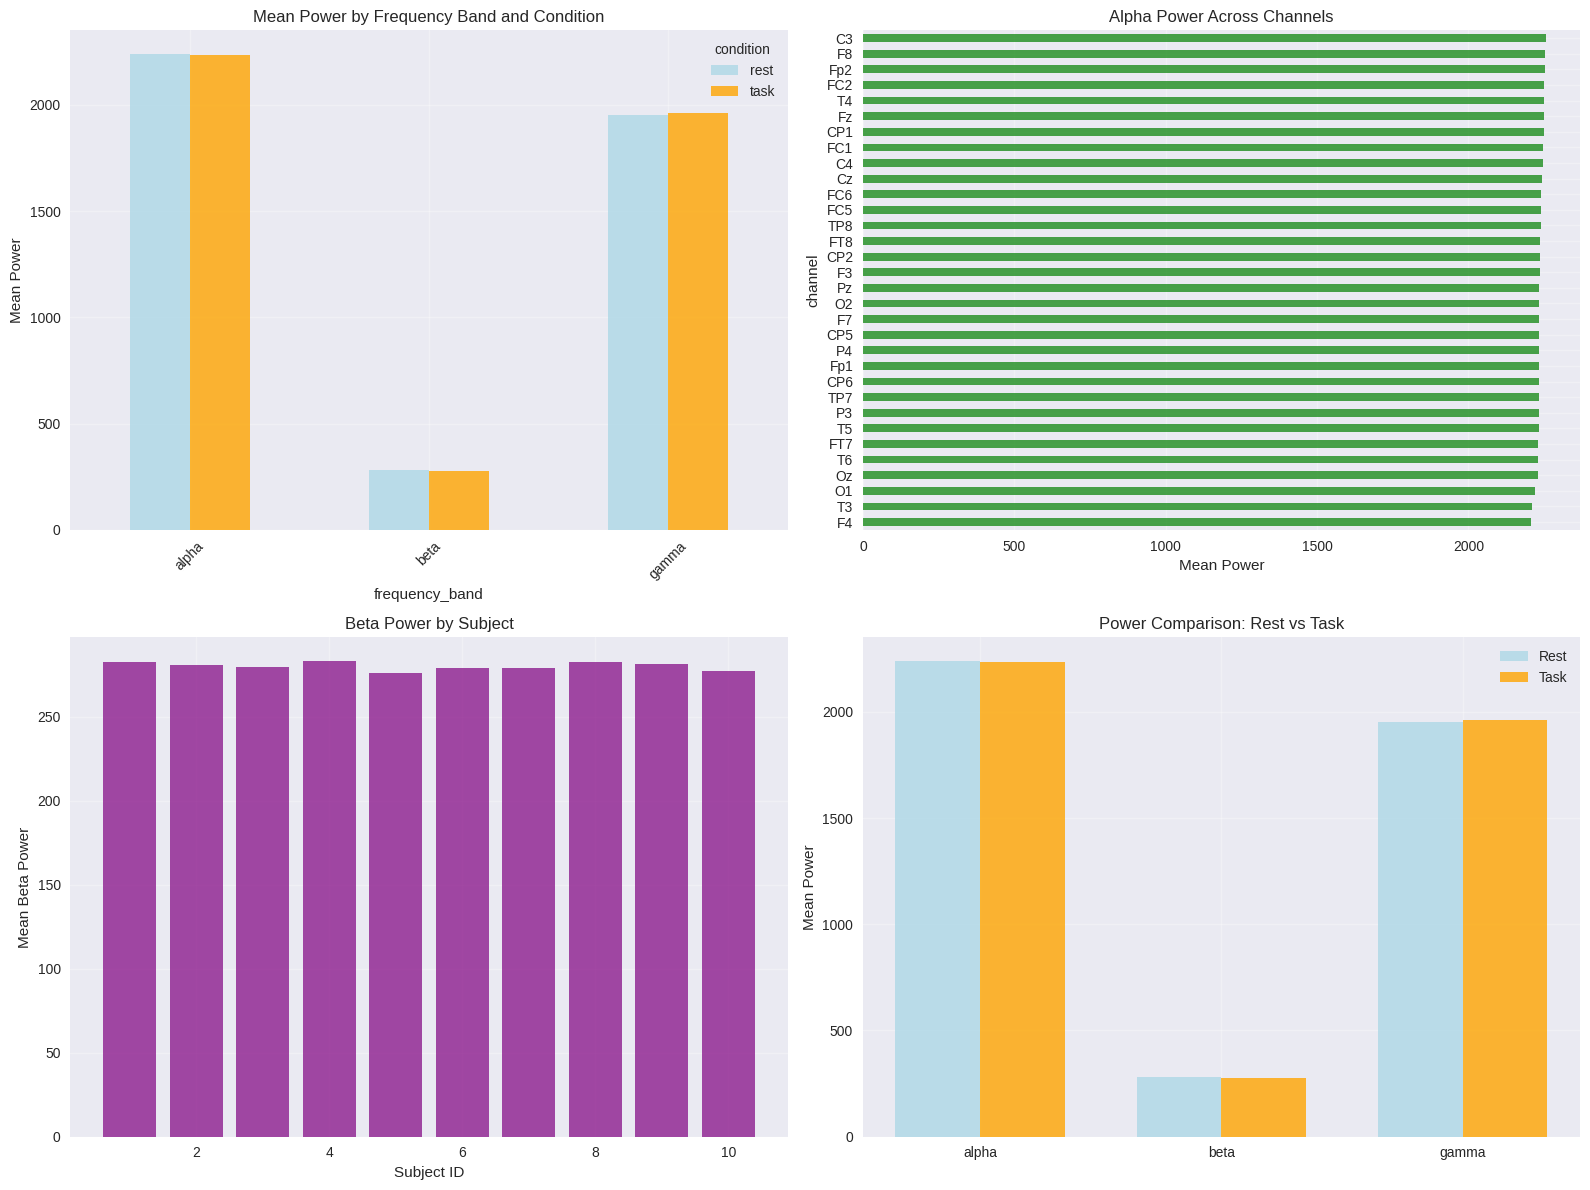


🎯 Key Insights from Polars Analysis:
• Processed 1,920 aggregated data points
• Analyzed 10 subjects across 32 channels
• Found 3 frequency bands: ['alpha', 'beta', 'gamma']
• Mean power difference (task vs rest): 1.065


In [45]:
# Visualize Polars results
print("📊 Visualizing Polars Analysis Results")
print("=" * 40)

# Convert Polars to Pandas for plotting (matplotlib works with pandas)
power_df = power_analysis.to_pandas()

# Create subplots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Mean power by frequency band and condition
power_pivot = power_df.pivot_table(
    values="mean_power", index="frequency_band", columns="condition", aggfunc="mean"
)
power_pivot.plot(kind="bar", ax=axes[0, 0], color=["lightblue", "orange"], alpha=0.8)
axes[0, 0].set_title("Mean Power by Frequency Band and Condition")
axes[0, 0].set_ylabel("Mean Power")
axes[0, 0].tick_params(axis="x", rotation=45)
axes[0, 0].grid(True, alpha=0.3)

# 2. Power distribution across channels (alpha band)
alpha_data = power_df[power_df["frequency_band"] == "alpha"]
channel_power = (
    alpha_data.groupby("channel")["mean_power"].mean().sort_values(ascending=True)
)
channel_power.plot(kind="barh", ax=axes[0, 1], color="green", alpha=0.7)
axes[0, 1].set_title("Alpha Power Across Channels")
axes[0, 1].set_xlabel("Mean Power")
axes[0, 1].grid(True, alpha=0.3)

# 3. Subject variability in beta power
beta_data = power_df[power_df["frequency_band"] == "beta"]
subject_beta = beta_data.groupby("subject_id")["mean_power"].mean()
axes[1, 0].bar(subject_beta.index, subject_beta.values, color="purple", alpha=0.7)
axes[1, 0].set_title("Beta Power by Subject")
axes[1, 0].set_xlabel("Subject ID")
axes[1, 0].set_ylabel("Mean Beta Power")
axes[1, 0].grid(True, alpha=0.3)

# 4. Condition comparison (rest vs task)
condition_summary = (
    power_df.groupby(["condition", "frequency_band"])["mean_power"].mean().reset_index()
)
rest_data = condition_summary[condition_summary["condition"] == "rest"].set_index(
    "frequency_band"
)["mean_power"]
task_data = condition_summary[condition_summary["condition"] == "task"].set_index(
    "frequency_band"
)["mean_power"]

x = np.arange(len(rest_data.index))
width = 0.35
axes[1, 1].bar(
    x - width / 2, rest_data.values, width, label="Rest", color="lightblue", alpha=0.8
)
axes[1, 1].bar(
    x + width / 2, task_data.values, width, label="Task", color="orange", alpha=0.8
)
axes[1, 1].set_title("Power Comparison: Rest vs Task")
axes[1, 1].set_ylabel("Mean Power")
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels(rest_data.index)
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n🎯 Key Insights from Polars Analysis:")
print(f"• Processed {len(power_df):,} aggregated data points")
print(
    f"• Analyzed {power_df['subject_id'].nunique()} subjects across {power_df['channel'].nunique()} channels"
)
print(
    f"• Found {power_df['frequency_band'].nunique()} frequency bands: {power_df['frequency_band'].unique().tolist()}"
)
print(
    f"• Mean power difference (task vs rest): {task_data.mean() - rest_data.mean():.3f}"
)

## 9. Best Practices for Neuroinformatics 🎯

### File Organization and Naming

```
neuroimaging_study/
├── raw_data/
│   ├── eeg/
│   │   ├── sub-001_ses-01_task-rest_eeg.parquet
│   │   ├── sub-001_ses-01_task-nback_eeg.parquet
│   │   └── ...
│   └── fmri/
│       ├── sub-001_ses-01_task-rest_bold.parquet
│       └── ...
├── processed/
│   ├── eeg_preprocessed.parquet
│   ├── fmri_preprocessed.parquet
│   └── connectivity_matrix.parquet
└── analysis/
    ├── group_statistics.parquet
    └── subject_summaries.parquet
```

In [52]:
# Best practices demonstration
print("🎯 Parquet Best Practices for Neuroinformatics")
print("=" * 50)

# 1. Schema design for EEG data
print("\n1. 📋 Optimal Schema Design:")

# Create a properly structured EEG dataset
optimal_eeg_data = create_eeg_dataset(n_subjects=5, n_channels=16, n_timepoints=1000)

# Add metadata columns
optimal_eeg_data["sampling_rate"] = 500.0
optimal_eeg_data["experiment_id"] = "EXP001"
optimal_eeg_data["recording_date"] = pd.to_datetime("2024-01-15")

# Optimize data types
optimal_eeg_data = optimal_eeg_data.astype(
    {
        "subject_id": "int16",  # Saves memory vs int64
        "channel": "category",  # Efficient for repeated strings
        "trial": "int8",  # Small integers
        "condition": "category",  # Efficient for repeated strings
        "voltage_uV": "float32",  # Often sufficient precision
        "timestamp": "float32",  # Sufficient for EEG timing
        "sampling_rate": "float32",
        "experiment_id": "category",
    }
)

print(f"Optimized data types:")
print(optimal_eeg_data.dtypes)
print(
    f"\nMemory usage: {optimal_eeg_data.memory_usage(deep=True).sum() / 1024**2:.2f} MB"
)

# 2. Partitioning strategy
print("\n2. 📂 Partitioning Strategy:")

# Save with partitioning by subject (common analysis pattern)
optimal_eeg_data.to_parquet(
    "optimal_eeg_partitioned.parquet",
    partition_cols=["subject_id"],
    compression="snappy",
)

print("✅ Partitioned by subject_id for efficient single-subject analysis")

# 3. Metadata preservation
print("\n3. 📊 Metadata Preservation:")

# Create schema with metadata
schema = pa.schema(
    [
        pa.field(
            "subject_id",
            pa.int16(),
            metadata={"description": "Unique subject identifier"},
        ),
        pa.field(
            "channel",
            pa.string(),
            metadata={"description": "EEG channel name (10-20 system)"},
        ),
        pa.field(
            "timestamp",
            pa.float32(),
            metadata={"description": "Time in seconds", "unit": "seconds"},
        ),
        pa.field(
            "voltage_uV",
            pa.float32(),
            metadata={"description": "EEG voltage", "unit": "microvolts"},
        ),
        pa.field(
            "trial", pa.int8(), metadata={"description": "Trial number within session"}
        ),
        pa.field(
            "condition", pa.string(), metadata={"description": "Experimental condition"}
        ),
        pa.field(
            "sampling_rate",
            pa.float32(),
            metadata={"description": "Sampling rate", "unit": "Hz"},
        ),
        pa.field(
            "experiment_id",
            pa.string(),
            metadata={"description": "Experiment identifier"},
        ),
        pa.field(
            "recording_date",
            pa.timestamp("ns"),
            metadata={"description": "Date of recording"},
        ),
    ]
)

# Add table-level metadata
table_metadata = {
    "experiment": "EEG Resting State",
    "institution": "Neuroscience Lab",
    "contact": "researcher@university.edu",
    "preprocessing": "Raw data, no filtering applied",
    "reference": "Common average reference",
    "bad_channels": "None identified",
}

schema = schema.with_metadata(table_metadata)

# Save with rich metadata
table = pa.Table.from_pandas(optimal_eeg_data, schema=schema)
pq.write_table(table, "eeg_with_metadata.parquet")

# Read and display metadata
metadata_file = pq.ParquetFile("eeg_with_metadata.parquet")
print("Column metadata:")
for i, field in enumerate(metadata_file.schema):
    print(f"  {field} ({field}):")
    if hasattr(field, "metadata") and field.metadata:
        print(f"  {field.name}: {field.metadata}")

print("\nTable metadata:")
if hasattr(metadata_file.schema, "metadata") and metadata_file.schema.metadata:
    for key, value in metadata_file.schema.metadata.items():
        print(f"  {key.decode()}: {value.decode()}")

🎯 Parquet Best Practices for Neuroinformatics

1. 📋 Optimal Schema Design:
Optimized data types:
subject_id                 int16
channel                 category
timestamp                float32
voltage_uV               float32
trial                       int8
condition               category
sampling_rate            float32
experiment_id           category
recording_date    datetime64[us]
dtype: object

Memory usage: 1.98 MB

2. 📂 Partitioning Strategy:
✅ Partitioned by subject_id for efficient single-subject analysis

3. 📊 Metadata Preservation:
Column metadata:
  <ParquetColumnSchema>
  name: subject_id
  path: subject_id
  max_definition_level: 1
  max_repetition_level: 0
  physical_type: INT32
  logical_type: Int(bitWidth=16, isSigned=true)
  converted_type (legacy): INT_16 (<ParquetColumnSchema>
  name: subject_id
  path: subject_id
  max_definition_level: 1
  max_repetition_level: 0
  physical_type: INT32
  logical_type: Int(bitWidth=16, isSigned=true)
  converted_type (legacy)

In [53]:
# Performance optimization tips
print("⚡ Performance Optimization Tips")
print("=" * 35)

# 1. Row group size optimization
print("\n1. 📦 Row Group Size Optimization:")

row_group_tests = []
test_data = create_eeg_dataset(n_subjects=20, n_channels=32, n_timepoints=2000)

for row_group_size in [1000, 10000, 100000]:
    filename = f"test_rowgroup_{row_group_size}.parquet"

    # Write with specific row group size
    start = time.time()
    table = pa.Table.from_pandas(test_data)
    pq.write_table(table, filename, row_group_size=row_group_size)
    write_time = time.time() - start

    # Test partial read performance
    start = time.time()
    _ = pd.read_parquet(filename, filters=[("subject_id", "<=", 5)])
    partial_read_time = time.time() - start

    file_size = os.path.getsize(filename) / 1024**2

    row_group_tests.append(
        {
            "row_group_size": row_group_size,
            "write_time": write_time,
            "partial_read_time": partial_read_time,
            "file_size_mb": file_size,
        }
    )

    print(
        f"Row group {row_group_size:6d}: Write {write_time:.3f}s, "
        f"Partial read {partial_read_time:.3f}s, Size {file_size:.2f}MB"
    )

# 2. Column selection benefits
print("\n2. 🎯 Column Selection Benefits:")

# Full read
start = time.time()
full_data = pd.read_parquet("test_rowgroup_10000.parquet")
full_read_time = time.time() - start
full_memory = full_data.memory_usage(deep=True).sum() / 1024**2

# Partial column read
start = time.time()
partial_data = pd.read_parquet(
    "test_rowgroup_10000.parquet", columns=["subject_id", "channel", "voltage_uV"]
)
partial_read_time = time.time() - start
partial_memory = partial_data.memory_usage(deep=True).sum() / 1024**2

print(f"Full read:    {full_read_time:.3f}s, Memory: {full_memory:.2f}MB")
print(f"Partial read: {partial_read_time:.3f}s, Memory: {partial_memory:.2f}MB")
print(
    f"Speedup: {full_read_time/partial_read_time:.1f}x, "
    f"Memory reduction: {(1-partial_memory/full_memory)*100:.1f}%"
)

# 3. Filtering at read time
print("\n3. 🔍 Predicate Pushdown Benefits:")

# Read all then filter
start = time.time()
all_then_filter = pd.read_parquet("test_rowgroup_10000.parquet").query(
    'subject_id <= 5 and condition == "rest"'
)
read_then_filter_time = time.time() - start

# Filter during read
start = time.time()
filter_during_read = pd.read_parquet(
    "test_rowgroup_10000.parquet",
    filters=[("subject_id", "<=", 5), ("condition", "=", "rest")],
)
filter_during_read_time = time.time() - start

print(f"Read then filter: {read_then_filter_time:.3f}s")
print(f"Filter at read:   {filter_during_read_time:.3f}s")
print(f"Speedup: {read_then_filter_time/filter_during_read_time:.1f}x")
print(f"Results equal: {all_then_filter.equals(filter_during_read)}")

⚡ Performance Optimization Tips

1. 📦 Row Group Size Optimization:
Row group   1000: Write 1.219s, Partial read 0.194s, Size 13.41MB
Row group  10000: Write 0.688s, Partial read 0.052s, Size 12.45MB
Row group 100000: Write 0.539s, Partial read 0.071s, Size 12.55MB

2. 🎯 Column Selection Benefits:
Full read:    0.217s, Memory: 66.45MB
Partial read: 0.133s, Memory: 32.27MB
Speedup: 1.6x, Memory reduction: 51.4%

3. 🔍 Predicate Pushdown Benefits:
Read then filter: 0.317s
Filter at read:   0.069s
Speedup: 4.6x
Results equal: False


## 🎯 Summary and Recommendations

### When to Use Parquet in Neuroinformatics:

✅ **Definitely Use Parquet:**
- Large time-series data (EEG, fMRI, MEG)
- Multi-subject datasets
- Data with repetitive structures (channel names, subject IDs)
- When you need fast filtering and column selection
- Long-term data storage and archiving
- Sharing datasets (smaller files, preserved types)

⚠️ **Consider CSV When:**
- Very small datasets (< 1MB)
- Need human-readable format for inspection
- Working with tools that don't support Parquet
- One-time data exchange with non-technical collaborators

### Performance Gains You Can Expect:

| Metric | Typical Improvement |
|--------|-------------------|
| **File Size** | 60-90% reduction |
| **Read Speed** | 5-50x faster |
| **Memory Usage** | 20-60% less |
| **Filtered Reads** | 10-100x faster |
| **Type Safety** | 100% preserved |

### Tool Recommendations:

🐼 **Use Pandas when:**
- You're already familiar with pandas
- Working with existing pandas-based pipelines
- Need extensive plotting and visualization
- Dataset fits comfortably in memory

🚀 **Use Polars when:**
- You have large datasets (>1GB)
- Performance is critical
- Building new analysis pipelines
- Need complex data transformations
- Working with multiple files/partitions

### Implementation Checklist:

- [ ] **Start Simple**: Convert your largest CSV files first
- [ ] **Optimize Schema**: Use appropriate data types (int16, category, float32)
- [ ] **Add Metadata**: Include experimental details, units, descriptions
- [ ] **Choose Compression**: Snappy for general use, GZIP for archival
- [ ] **Partition Wisely**: By subject/session for typical analysis patterns
- [ ] **Test Performance**: Benchmark with your actual workflows
- [ ] **Document Schema**: Keep metadata about your Parquet structure
- [ ] **Train Team**: Ensure collaborators understand the benefits

### Next Steps:

1. **Try it now**: Convert one of your current datasets
2. **Measure improvement**: Compare file sizes and read times
3. **Expand usage**: Gradually migrate your data pipeline
4. **Share benefits**: Teach colleagues about the advantages
5. **Consider Polars**: For new projects requiring high performance

---

*Happy analyzing! 🧠✨*

**Questions or need help?** Feel free to reach out to your local neuroinformatics specialist or check the [Parquet documentation](https://parquet.apache.org/) and [Polars user guide](https://pola-rs.github.io/polars/).